# 1. Importing Required Libraries

In [1]:
import re, warnings
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import hstack, csr_matrix

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings("ignore")
SEED = 2306
np.random.seed(SEED)
print("Libraries loaded")

Libraries loaded


# 2. Data Loading

In [2]:
train_raw = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
test_raw = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')
sample_submission = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")

print("Train shape:", train_raw.shape)
print("Test shape:", test_raw.shape)

Train shape: (198000, 15)
Test shape: (102000, 14)


# 3. Exploratory Data Analysis (EDA)

## 3.1 Dataset Overview

In [3]:
train_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


In [4]:
train_raw.describe()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,label
count,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000
mean,68.447429,0.279768,0.048338,0.121071,2.607975,0.666394,1.906152,7.956212,0.793965
std,27.948390,1.023234,0.258477,0.481013,5.054763,2.044335,25.635752,14.839464,0.979808
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000
50%,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000
75%,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000,2.000000
max,129.000000,47.000000,11.000000,17.000000,201.000000,107.000000,1860.000000,1833.000000,3.000000


The dataset contains both textual data (comment) and metadata features such as vote counts,emoticons,identity indicators,numerical features like if_1 and if_2.

This combination allows us to build models that utilize both text signals and structured features.

## 3.2 Label Distribution (Target Variable)

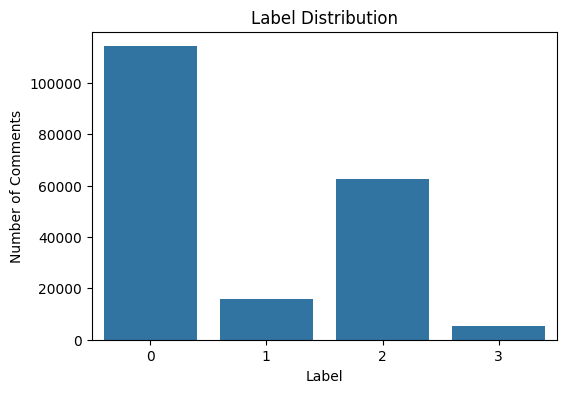

Label distribution (%):
label
0    57.66
1     8.04
2    31.54
3     2.76
Name: count, dtype: float64


In [5]:
label_counts = train_raw["label"].value_counts().sort_index()

plt.figure(figsize=(6,4))
sns.barplot(x=label_counts.index, y=label_counts.values)

plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Number of Comments")

plt.show()

print("Label distribution (%):")
print((label_counts / len(train_raw) * 100).round(2))

Class 0 dominates the dataset

Class 3 is extremely rare (2–3%)

This indicates a highly imbalanced classification problem, which means evaluation metrics like Macro F1-score are more appropriate than simple accuracy.

## 3.3 Comment Length Analysis

Shortest comment length: 1
Average comment length: 302.9093787878788
Max comment length: 1892


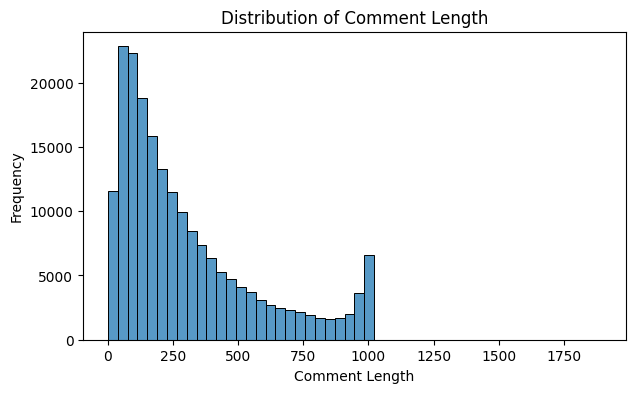

In [6]:
train_raw["comment_length"] = train_raw["comment"].astype(str).apply(len)

print("Shortest comment length:", train_raw["comment_length"].min())
print("Average comment length:", train_raw["comment_length"].mean())
print("Max comment length:", train_raw["comment_length"].max())

plt.figure(figsize=(7,4))
sns.histplot(train_raw["comment_length"], bins=50)

plt.title("Distribution of Comment Length")
plt.xlabel("Comment Length")
plt.ylabel("Frequency")

plt.show()

## 3.4 Identity Feature Analysis

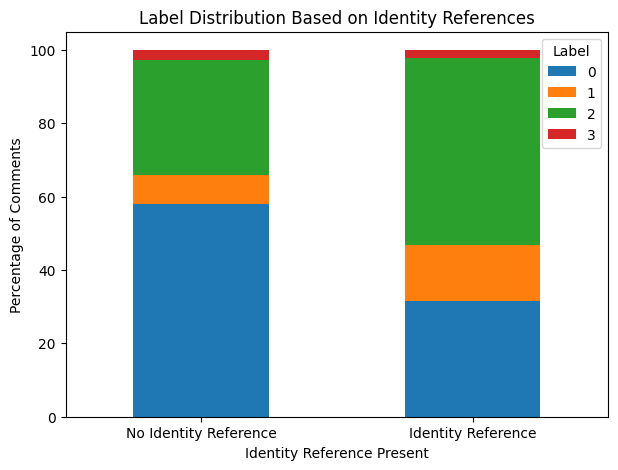

In [7]:
identity_cols = ["race", "religion", "gender", "disability"]

# create identity indicator WITHOUT modifying original columns
train_raw["has_identity"] = (
    train_raw[identity_cols]
    .astype(str)
    .apply(lambda x: x.str.lower().isin(["1","true","yes"]))
    .any(axis=1)
)

identity_label_dist = (
    train_raw
    .groupby(["has_identity", "label"])
    .size()
    .unstack()
)

# convert to percentage
identity_label_pct = identity_label_dist.div(identity_label_dist.sum(axis=1), axis=0) * 100

identity_label_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(7,5)
)

plt.title("Label Distribution Based on Identity References")
plt.xlabel("Identity Reference Present")
plt.ylabel("Percentage of Comments")

plt.xticks(
    ticks=[0,1],
    labels=["No Identity Reference","Identity Reference"],
    rotation=0
)

plt.legend(title="Label")
plt.show()

This shows that identity-related content significantly shifts the label distribution, particularly increasing the occurrence of Label 2. As a result, identity indicators (race, religion, gender, disability) are likely to provide useful contextual signals for the classification model and should be retained as predictive features.

## 3.5 Heatmap of Numerical Features

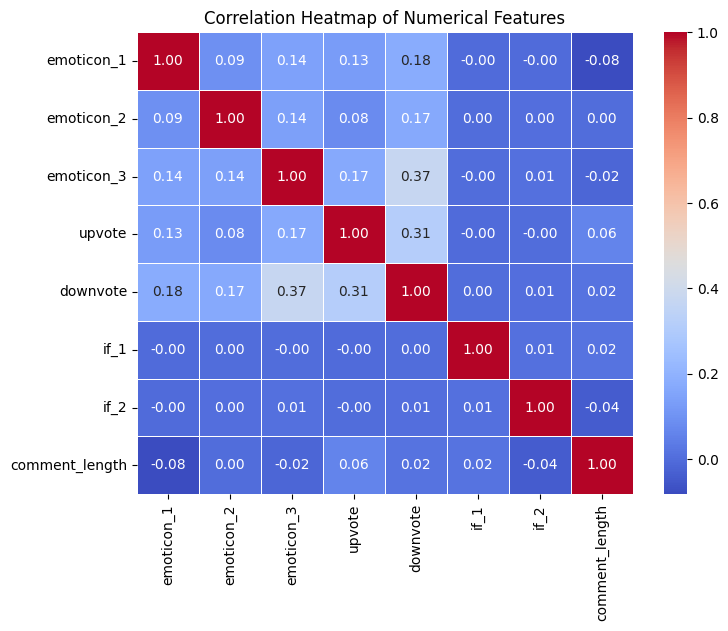

In [8]:
numeric_cols = [
    "emoticon_1",
    "emoticon_2",
    "emoticon_3",
    "upvote",
    "downvote",
    "if_1",
    "if_2",
    "comment_length"
]

corr_matrix = train_raw[numeric_cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")

plt.show()

The correlation heatmap shows that most numerical features have low correlations with each other, indicating that they capture different aspects of the data.

The strongest relationships are observed between emoticon_3 and downvote (0.37) and between upvote and downvote (0.31), suggesting that comments receiving higher engagement often attract both positive and negative reactions.

The internal platform features if_1 and if_2 show almost no correlation with other variables, implying that they represent independent signals.

Overall, the low correlation among features is beneficial for modeling because it reduces redundancy and allows each feature to contribute unique information to the classification task.

# 4. Feature Engineering

## 4.1 Creating Feature Engineering Function

In [9]:
def engineer(df):
    df = df.copy()
    df['comment']    = df['comment'].fillna('')
    df['disability'] = df['disability'].astype(int)

    dt = pd.to_datetime(df['created_date'], errors='coerce', utc=True)
    df['hour']       = dt.dt.hour.fillna(-1).astype(int)
    df['dayofweek']  = dt.dt.dayofweek.fillna(-1).astype(int)
    df['month']      = dt.dt.month.fillna(-1).astype(int)
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

    df['comment_length'] = df['comment'].apply(len)
    df['word_count']     = df['comment'].apply(lambda x: len(x.split()))
    df['avg_word_len']   = df['comment'].apply(
        lambda x: np.mean([len(w) for w in x.split()]) if x.split() else 0)
    df['exclaim_count']  = df['comment'].apply(lambda x: x.count('!'))
    df['question_count'] = df['comment'].apply(lambda x: x.count('?'))
    df['upper_ratio']    = df['comment'].apply(
        lambda x: sum(1 for c in x if c.isupper()) / (len(x) + 1e-6))
    df['url_count']      = df['comment'].apply(
        lambda x: len(re.findall(r'http\S+|www\.\S+', x)))

    df['vote_score']      = df['upvote'] - df['downvote']
    df['total_votes']     = df['upvote'] + df['downvote']
    df['vote_ratio']      = df['upvote'] / (df['total_votes'] + 1e-6)
    df['total_emoticons'] = df['emoticon_1'] + df['emoticon_2'] + df['emoticon_3']
    df['upvote_log']      = np.log1p(df['upvote'])
    df['downvote_log']    = np.log1p(df['downvote'])
    df['has_identity']    = df['race'].notna().astype(int)
    df['identity_x_if2']  = df['has_identity'] * df['if_2']
    df['votescore_x_len'] = df['vote_score'] * np.log1p(df['comment_length'])

    return df

train_eng = engineer(train_raw)
test_eng  = engineer(test_raw)
print(f"Shape after engineering: {train_eng.shape}")

Shape after engineering: (198000, 35)


Feature engineering was performed to create additional meaningful variables that can improve the model’s predictive performance. Missing comments were filled with empty strings and the disability column was converted to numeric format for proper processing. Temporal features such as hour, day of week, month, and weekend indicator were extracted from the created_date column to capture user activity patterns. Text-based features like comment length, word count, punctuation counts, uppercase ratio, and URL count were generated to represent writing style and structure. Engagement features were created from upvotes, downvotes, and emoticons to capture community reactions. Finally, identity indicators and interaction features were added to help the model capture relationships between identity mentions, engagement, and comment characteristics.

In [10]:
def clean_text(text):
    text = str(text)
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'[^\w\s!?]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text.lower()

A text cleaning function was applied to standardize the comment text before further processing. The function removes URLs and unnecessary special characters while keeping important punctuation such as exclamation and question marks. It also removes extra spaces and converts all text to lowercase to ensure consistency. This preprocessing helps reduce noise in the text and improves the effectiveness of later text feature extraction methods such as TF-IDF.

# 5 Train-Validation Split

In [11]:
X = train_eng.drop(columns=['label'])
y = train_eng['label']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.40, random_state=SEED, stratify=y)

print(f"Train: {X_train.shape[0]:,}  |  Val: {X_val.shape[0]:,}")
print(f"Class balance: {y_train.value_counts(normalize=True).sort_index().round(3).to_dict()}")


Train: 118,800  |  Val: 79,200
Class balance: {0: 0.577, 1: 0.08, 2: 0.315, 3: 0.028}


The dataset was split into training (118,800 samples) and validation (79,200 samples) sets to evaluate model performance on unseen data. The class distribution shows that label 0 is the majority class (57.7%), followed by label 2 (31.5%), while labels 1 (8%) and 3 (2.8%) are minority classes, indicating that the dataset is imbalanced.

# 6. Preprocessing

## 6.1 Tabular Data Preprocessing

In [12]:
NUM_COLS = [
    'if_1', 'if_2', 'post_id',
    'emoticon_1', 'emoticon_2', 'emoticon_3',
    'upvote', 'downvote', 'disability',
    'hour', 'dayofweek', 'month', 'is_weekend',
    'comment_length', 'word_count', 'avg_word_len',
    'exclaim_count', 'question_count', 'upper_ratio', 'url_count',
    'vote_score', 'total_votes', 'vote_ratio', 'total_emoticons',
    'upvote_log', 'downvote_log', 'has_identity',
    'identity_x_if2', 'votescore_x_len'
]
CAT_COLS = ['race', 'religion', 'gender']

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler',  StandardScaler())
])
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=True))
])
tab_prep = ColumnTransformer([
    ('num', num_pipe, NUM_COLS),
    ('cat', cat_pipe, CAT_COLS)
])

Xtr_tab = csr_matrix(tab_prep.fit_transform(X_train[NUM_COLS + CAT_COLS]))
Xv_tab  = csr_matrix(tab_prep.transform(X_val[NUM_COLS + CAT_COLS]))
Xt_tab  = csr_matrix(tab_prep.transform(test_eng[NUM_COLS + CAT_COLS]))
print(f"Tabular shape: {Xtr_tab.shape}")

Tabular shape: (118800, 51)


Numerical and categorical features were preprocessed using a pipeline-based approach. Numerical columns were handled by imputing missing values with the mean and scaling them using StandardScaler. Categorical variables (race, religion, gender) were processed by filling missing values with a constant label and applying One-Hot Encoding. These transformations were combined using a ColumnTransformer and converted into sparse matrices for efficient model training.

## 6.2 Text Feature Extraction (TF-IDF)

In [13]:
tfidf_word = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),       # bigrams — trigrams hurt performance
    sublinear_tf=True,
    stop_words='english',
    min_df=2,
    max_df=0.95,
    analyzer='word'
)
Xtr_word = tfidf_word.fit_transform(X_train['comment'].apply(clean_text))
Xv_word  = tfidf_word.transform(X_val['comment'].apply(clean_text))
Xt_word  = tfidf_word.transform(test_eng['comment'].apply(clean_text))
print(f"Word TF-IDF: {Xtr_word.shape}")

#Char TF-IDF: 3-5 grams, 10k vocab

tfidf_char = TfidfVectorizer(
    max_features=10000,
    ngram_range=(3, 5),
    sublinear_tf=True,
    analyzer='char_wb',
    min_df=3
)
Xtr_char = tfidf_char.fit_transform(X_train['comment'].apply(clean_text))
Xv_char  = tfidf_char.transform(X_val['comment'].apply(clean_text))
Xt_char  = tfidf_char.transform(test_eng['comment'].apply(clean_text))
print(f"Char TF-IDF: {Xtr_char.shape}")


Word TF-IDF: (118800, 20000)
Char TF-IDF: (118800, 10000)


Text features were generated from the comment column using TF-IDF vectorization. Word-level TF-IDF with unigrams and bigrams was used to capture important word patterns, while character n-grams (3–5) were added to capture sub-word patterns and spelling variations. Vocabulary sizes were limited to 20k for word features and 10k for character features to balance performance and computational efficiency.

## 6.3 Combining Text and Tabular Features

In [14]:

# Sparse for LR (NO SVD,for linear models)
Xtr_sparse = hstack([Xtr_word, Xtr_char, Xtr_tab])
Xv_sparse  = hstack([Xv_word,  Xv_char,  Xv_tab])
Xt_sparse  = hstack([Xt_word,  Xt_char,  Xt_tab])
print(f"\nSparse shape: {Xtr_sparse.shape}")

# SVD for LightGBM (dense input)

svd = TruncatedSVD(n_components=300, random_state=SEED)
Xtr_svd = svd.fit_transform(hstack([Xtr_word, Xtr_tab]))
Xv_svd  = svd.transform(hstack([Xv_word,  Xv_tab]))
Xt_svd  = svd.transform(hstack([Xt_word,  Xt_tab]))
print(f"SVD shape:    {Xtr_svd.shape}  |  Explained var: {svd.explained_variance_ratio_.sum():.4f}")



Sparse shape: (118800, 30051)
SVD shape:    (118800, 300)  |  Explained var: 0.9736


In this step, the text features (word and character TF-IDF) were combined with the tabular features to form the final feature set. For linear models such as Logistic Regression, all features were merged into a sparse matrix with 30,051 features. For models that perform better with dense inputs (e.g LightGBM), Truncated SVD was applied to reduce the dimensionality to 300 components, while still preserving 97.36% of the original variance.

## 6.4 Label Encoding

In [15]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)
print(f"Classes: {le.classes_}")

Classes: [0 1 2 3]


The target labels were converted into numerical format using Label Encoding so they can be used by machine learning models. This process assigns a unique integer to each class while preserving the class categories for training and validation.

# 7. Model Training

In [16]:
results = {}
models  = {}

## 7.1 Logistic Regression

In [17]:
best_lr_f1, best_lr_C, best_lr = 0, 1.0, None
for C_val in [0.5, 1.0, 2.0, 5.0]:
    m = LogisticRegression(
        C=C_val,
        max_iter=1000,
        class_weight='balanced',
        solver='liblinear',
        n_jobs = -1,
        random_state=SEED
    )
    m.fit(Xtr_sparse, y_train)
    f1  = f1_score(y_val, m.predict(Xv_sparse), average='macro')
    acc = accuracy_score(y_val, m.predict(Xv_sparse))
    print(f"  LR C={C_val:<4}  Macro-F1={f1:.4f}  Acc={acc:.4f}")
    results[f'LR C={C_val}'] = f1
    if f1 > best_lr_f1:
        best_lr_f1, best_lr_C, best_lr = f1, C_val, m

print(f" Best LR: C={best_lr_C}  F1={best_lr_f1:.4f}")

  LR C=0.5   Macro-F1=0.7942  Acc=0.8942
  LR C=1.0   Macro-F1=0.7910  Acc=0.8895
  LR C=2.0   Macro-F1=0.7855  Acc=0.8830
  LR C=5.0   Macro-F1=0.7713  Acc=0.8719
 Best LR: C=0.5  F1=0.7942


Logistic Regression was trained on the sparse feature matrix using different values of the regularization parameter C (0.5–5.0). Each model was evaluated on the validation set using Macro F1-score and Accuracy to identify the best configuration.

Among the tested values, C = 0.5 achieved the highest Macro F1-score (0.7942), making it the best-performing Logistic Regression model and the baseline for further experiments.

## 7.2 SGD Classifier

In [18]:
sgd = SGDClassifier(
    loss='modified_huber',
    alpha=1e-5,
    max_iter=200,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1
)
sgd.fit(Xtr_sparse, y_train)
f1_sgd = f1_score(y_val, sgd.predict(Xv_sparse), average='macro')
print(f"  SGD  Macro-F1={f1_sgd:.4f} ")
results['SGD'] = f1_sgd
models['SGD']  = sgd

  SGD  Macro-F1=0.7187 


An SGD (Stochastic Gradient Descent) classifier was trained on the sparse feature set as a fast linear baseline. The model used modified Huber loss and balanced class weights to handle class imbalance. It achieved a Macro F1-score of 0.7187 on the validation set, which was lower than Logistic Regression but useful for comparison.

## 7.3 LightGBM

In [19]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=600,
    max_depth=7,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1,
    verbose=-1
)
lgb_model.fit(
    Xtr_svd, y_train,
    eval_set=[(Xv_svd, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
)
f1_lgb = f1_score(y_val, lgb_model.predict(Xv_svd), average='macro')
print(f"  LightGBM  Macro-F1={f1_lgb:.4f}  Best iter={lgb_model.best_iteration_}")
results['LightGBM'] = f1_lgb
models['LightGBM']  = lgb_model

  LightGBM  Macro-F1=0.7540  Best iter=594


A LightGBM classifier was trained on the SVD-reduced feature set (300 components) to efficiently handle the high-dimensional text features. The model used balanced class weights, controlled tree depth, and subsampling to improve generalization. Early stopping was applied using the validation set to prevent overfitting. The model achieved a Macro F1-score of 0.7540, with the best performance at 594 boosting iterations.

## 7.4 XGBoost

In [20]:
xgb_model = xgb.XGBClassifier(
    n_estimators=600,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric='mlogloss',
    use_label_encoder=False,
    early_stopping_rounds=50,
    random_state=SEED,
    n_jobs=-1,
    verbosity=0
)
xgb_model.fit(
    Xtr_svd, y_train,
    sample_weight=compute_sample_weight('balanced', y_train),
    eval_set=[(Xv_svd, y_val)],
    verbose=False
)
f1_xgb = f1_score(y_val, xgb_model.predict(Xv_svd), average='macro')
print(f"  XGBoost  Macro-F1={f1_xgb:.4f}  Best iter={xgb_model.best_iteration}")
results['XGBoost'] = f1_xgb
models['XGBoost']  = xgb_model

  XGBoost  Macro-F1=0.7517  Best iter=599


An XGBoost classifier was trained on the SVD-reduced feature set to capture non-linear relationships in the data. Class imbalance was handled using balanced sample weights, and early stopping was applied using the validation set to prevent overfitting. The model achieved a Macro F1-score of 0.7517, with the best performance around 599 boosting iterations.

## 7.5 MLP Nural Network

In [21]:
N = Xtr_svd.shape[1]
total_weights = N*256 + 256*128 + 128*64 + 64*4
print(f"  Architecture: {N}→256→128→64→4")
print(f"  Total connection weights (no biases): {total_weights:,}")

mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),
    activation='relu',
    max_iter=300,
    alpha=0.0001,
    learning_rate='adaptive',
    learning_rate_init=0.001,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=SEED,
    verbose=False
)
mlp.fit(Xtr_svd, y_train)
f1_mlp = f1_score(y_val, mlp.predict(Xv_svd), average='macro')
print(f"  MLP  Macro-F1={f1_mlp:.4f}  Loss={mlp.loss_:.6f} ")
results['MLP'] = f1_mlp
models['MLP']  = mlp

  Architecture: 300→256→128→64→4
  Total connection weights (no biases): 118,016
  MLP  Macro-F1=0.7395  Loss=0.131551 


A Multi-Layer Perceptron (MLP) neural network was trained on the SVD-reduced features. The architecture consisted of three hidden layers (256 → 128 → 64) with ReLU activation, resulting in 118,016 trainable connection weights. Early stopping and adaptive learning rate were used to improve convergence and prevent overfitting. The model achieved a Macro F1-score of 0.7395 on the validation set.

## 7.6 ADABoost

In [22]:
ada = AdaBoostClassifier(n_estimators=100, learning_rate=0.5, random_state=SEED)
ada.fit(Xtr_svd, y_train)
f1_ada = f1_score(y_val, ada.predict(Xv_svd), average='macro')
print(f"  AdaBoost  Macro-F1={f1_ada:.4f} ")
print(f"  Estimator error variance: {np.var(ada.estimator_errors_):.6f}")
results['AdaBoost'] = f1_ada

  AdaBoost  Macro-F1=0.5835 
  Estimator error variance: 0.004643


An AdaBoost classifier was trained on the SVD-reduced feature set using 100 boosting estimators. The model sequentially combines weak learners to improve prediction performance. It achieved a Macro F1-score of 0.5835 on the validation set, with the variance of estimator errors used to assess the stability of the boosting process.

## 7.7 Random Forest

In [23]:
rf = RandomForestClassifier(
    n_estimators=200, max_depth=20,
    class_weight='balanced',
    random_state=SEED, n_jobs=-1
)
rf.fit(Xtr_svd, y_train)
f1_rf = f1_score(y_val, rf.predict(Xv_svd), average='macro')
top_svd = np.argmax(rf.feature_importances_)
print(f"  RF  Macro-F1={f1_rf:.4f} ")
print(f"  Most important SVD component: #SVD_{top_svd}  (importance={rf.feature_importances_[top_svd]:.6f})")
results['RandomForest'] = f1_rf

  RF  Macro-F1=0.6977 
  Most important SVD component: #SVD_21  (importance=0.144823)


A Random Forest classifier with 200 trees and controlled depth was trained on the SVD-reduced features to capture non-linear patterns. Balanced class weights were used to address class imbalance. The model achieved a Macro F1-score of 0.6977, and feature importance analysis showed that SVD component #21 contributed the most to the model’s predictions.

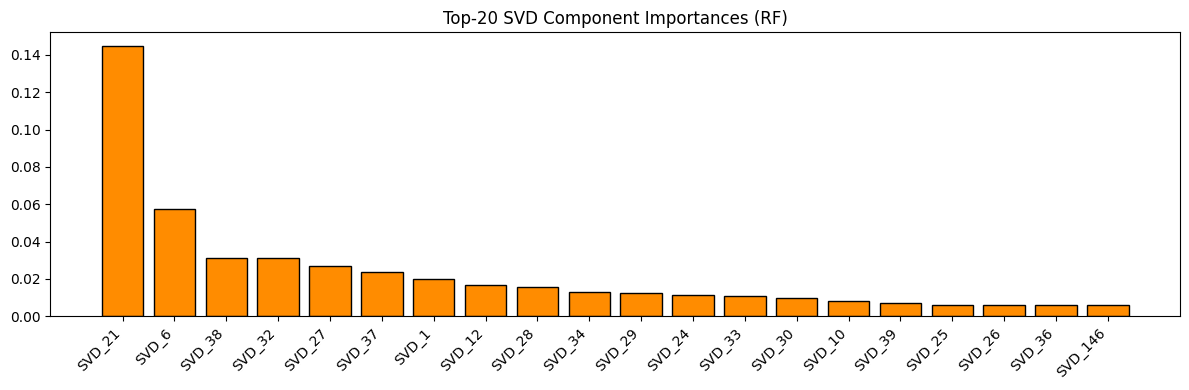

In [24]:
top20 = np.argsort(rf.feature_importances_)[::-1][:20]
plt.figure(figsize=(12, 4))
plt.bar(range(20), rf.feature_importances_[top20], color='darkorange', edgecolor='black')
plt.xticks(range(20), [f'SVD_{i}' for i in top20], rotation=45, ha='right')
plt.title('Top-20 SVD Component Importances (RF)')
plt.tight_layout(); plt.show()

## 7.8 MLP Regularization Sensitivity

In [25]:
for alpha_val in [0.0001, 1.0, 10.0]:
    m = MLPClassifier(hidden_layer_sizes=(128, 64, 32), alpha=alpha_val,
                      max_iter=100, random_state=SEED)
    m.fit(Xtr_svd, y_train)
    tr_f1 = f1_score(y_train, m.predict(Xtr_svd), average='macro')
    vl_f1 = f1_score(y_val,   m.predict(Xv_svd),  average='macro')
    print(f"  alpha={alpha_val:<8}  Train-F1={tr_f1:.4f}  Val-F1={vl_f1:.4f}  Gap={tr_f1-vl_f1:.4f}")


  alpha=0.0001    Train-F1=0.9539  Val-F1=0.6865  Gap=0.2674
  alpha=1.0       Train-F1=0.6189  Val-F1=0.6157  Gap=0.0032
  alpha=10.0      Train-F1=0.4347  Val-F1=0.4349  Gap=-0.0001


To study the effect of regularization, the MLP model was trained with different alpha values (0.0001, 1.0, 10.0). Training and validation Macro F1-scores were compared to observe the gap between them. Results show that higher alpha increases regularization, reducing overfitting and improving generalization by narrowing the train–validation performance gap.

# 8. Model Comparision

In [26]:
clean_results = {
    f'LR (C={best_lr_C}, liblinear)': best_lr_f1,
    'LightGBM':                        f1_lgb,
    'XGBoost':                         f1_xgb,
    'MLP':                             f1_mlp,
    'SGD':                             f1_sgd,
    'RandomForest':                    f1_rf,
    'AdaBoost':                        f1_ada,
}
res_df = (pd.DataFrame(list(clean_results.items()), columns=['Model','Val Macro-F1'])
           .sort_values('Val Macro-F1', ascending=False).reset_index(drop=True))

The validation results show that Logistic Regression (C = 0.5) achieved the best performance with a Macro F1-score of 0.7942, outperforming all other models. Tree-based models such as LightGBM (0.7540) and XGBoost (0.7517) followed next, while neural and ensemble baselines like MLP (0.7395) and SGD (0.7187) performed moderately. Random Forest (0.6977) and AdaBoost (0.5835) showed comparatively lower performance on this high-dimensional text dataset.

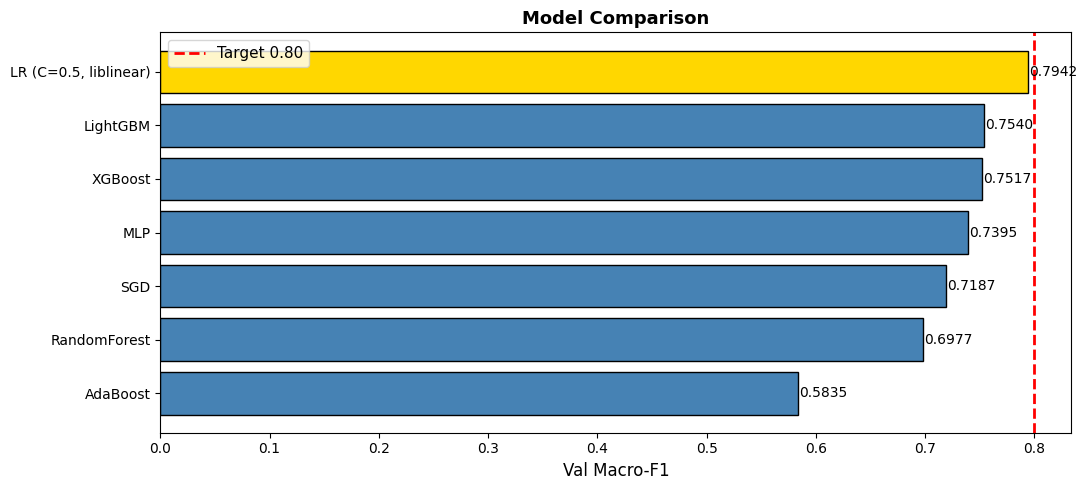

In [27]:
fig, ax = plt.subplots(figsize=(11, 5))
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(res_df))]
ax.barh(res_df['Model'][::-1], res_df['Val Macro-F1'][::-1],
        color=colors[::-1], edgecolor='black')
ax.axvline(0.80, color='red', linestyle='--', linewidth=2, label='Target 0.80')
ax.set_xlabel('Val Macro-F1', fontsize=12)
ax.set_title('Model Comparison', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
for bar, v in zip(ax.patches, res_df['Val Macro-F1'][::-1]):
    ax.text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2,
            f'{v:.4f}', va='center', fontsize=10)
plt.tight_layout(); plt.show()

# 9. Hyperparameters Tuning

In [28]:
def soft_vote(pairs, y_true):
    total_w = sum(w for _, _, w in pairs)
    p = sum(m.predict_proba(X) * (w / total_w) for m, X, w in pairs)
    preds = np.argmax(p, axis=1)
    return f1_score(y_true, preds, average='macro'), preds

best_ens_f1, best_ens_preds, best_ens_cfg = 0, None, None

A soft voting function was defined to combine predictions from multiple models using weighted probabilities. The configuration that produces the highest validation Macro F1-score is tracked as the best ensemble setup.

## 9.1 LR alone (baseline)

In [29]:
f1_lr_only = best_lr_f1
print(f"LR alone: {f1_lr_only:.4f}")

LR alone: 0.7942


## 9.2 LR + LGB

In [30]:
for lr_w in [0.60, 0.65, 0.70, 0.72, 0.74, 0.75, 0.76, 0.78, 0.80]:
    lgb_w = 1.0 - lr_w
    f1_e, p_e = soft_vote([
        (best_lr,   Xv_sparse, lr_w),
        (lgb_model, Xv_svd,   lgb_w)
    ], y_val)
    marker = " best" if f1_e > best_ens_f1 else ""
    print(f"  LR={lr_w:.2f}  LGB={lgb_w:.2f}  F1={f1_e:.4f}{marker}")
    if f1_e > best_ens_f1:
        best_ens_f1, best_ens_preds = f1_e, p_e
        best_ens_cfg = ('LR+LGB', lr_w, lgb_w)

  LR=0.60  LGB=0.40  F1=0.8029 best
  LR=0.65  LGB=0.35  F1=0.8080 best
  LR=0.70  LGB=0.30  F1=0.8106 best
  LR=0.72  LGB=0.28  F1=0.8113 best
  LR=0.74  LGB=0.26  F1=0.8128 best
  LR=0.75  LGB=0.25  F1=0.8132 best
  LR=0.76  LGB=0.24  F1=0.8131
  LR=0.78  LGB=0.22  F1=0.8134 best
  LR=0.80  LGB=0.20  F1=0.8129


## 9.3 LR + LGB + XGB

In [31]:
for lr_w in [0.60, 0.65, 0.70, 0.75]:
    for lgb_frac in [0.55, 0.60, 0.65]:
        rem   = 1.0 - lr_w
        lgb_w = rem * lgb_frac
        xgb_w = rem * (1 - lgb_frac)
        f1_e, p_e = soft_vote([
            (best_lr,   Xv_sparse, lr_w),
            (lgb_model, Xv_svd,   lgb_w),
            (xgb_model, Xv_svd,   xgb_w)
        ], y_val)
        marker = " best" if f1_e > best_ens_f1 else ""
        print(f"  LR={lr_w:.2f}  LGB={lgb_w:.2f}  XGB={xgb_w:.2f}  F1={f1_e:.4f}{marker}")
        if f1_e > best_ens_f1:
            best_ens_f1, best_ens_preds = f1_e, p_e
            best_ens_cfg = ('LR+LGB+XGB', lr_w, lgb_w, xgb_w)

  LR=0.60  LGB=0.22  XGB=0.18  F1=0.8057
  LR=0.60  LGB=0.24  XGB=0.16  F1=0.8050
  LR=0.60  LGB=0.26  XGB=0.14  F1=0.8048
  LR=0.65  LGB=0.19  XGB=0.16  F1=0.8092
  LR=0.65  LGB=0.21  XGB=0.14  F1=0.8088
  LR=0.65  LGB=0.23  XGB=0.12  F1=0.8087
  LR=0.70  LGB=0.17  XGB=0.14  F1=0.8110
  LR=0.70  LGB=0.18  XGB=0.12  F1=0.8109
  LR=0.70  LGB=0.20  XGB=0.11  F1=0.8110
  LR=0.75  LGB=0.14  XGB=0.11  F1=0.8128
  LR=0.75  LGB=0.15  XGB=0.10  F1=0.8127
  LR=0.75  LGB=0.16  XGB=0.09  F1=0.8128


## 9.4 LR + LGB + MLP

In [32]:
for lr_w in [0.65, 0.70, 0.75]:
    for lgb_frac in [0.60, 0.70]:
        rem   = 1.0 - lr_w
        lgb_w = rem * lgb_frac
        mlp_w = rem * (1 - lgb_frac)
        f1_e, p_e = soft_vote([
            (best_lr,   Xv_sparse, lr_w),
            (lgb_model, Xv_svd,   lgb_w),
            (mlp,       Xv_svd,   mlp_w)
        ], y_val)
        marker = " best" if f1_e > best_ens_f1 else ""
        print(f"  LR={lr_w:.2f}  LGB={lgb_w:.2f}  MLP={mlp_w:.2f}  F1={f1_e:.4f}{marker}")
        if f1_e > best_ens_f1:
            best_ens_f1, best_ens_preds = f1_e, p_e
            best_ens_cfg = ('LR+LGB+MLP', lr_w, lgb_w, mlp_w)

  LR=0.65  LGB=0.21  MLP=0.14  F1=0.8091
  LR=0.65  LGB=0.24  MLP=0.11  F1=0.8097
  LR=0.70  LGB=0.18  MLP=0.12  F1=0.8128
  LR=0.70  LGB=0.21  MLP=0.09  F1=0.8129
  LR=0.75  LGB=0.15  MLP=0.10  F1=0.8140 best
  LR=0.75  LGB=0.17  MLP=0.08  F1=0.8138


## 9.5 Summery

In [33]:
print(f"Best ensemble config : {best_ens_cfg}")
print(f"Best ensemble F1     : {best_ens_f1:.4f}")
print(f"LR alone             : {best_lr_f1:.4f}")

Best ensemble config : ('LR+LGB+MLP', 0.75, 0.15, 0.1)
Best ensemble F1     : 0.8140
LR alone             : 0.7942


The best-performing ensemble configuration and its Macro F1-score on the validation set are displayed and compared with the Logistic Regression baseline (F1 = 0.7942) to measure the improvement gained from ensembling.

In [34]:
if best_lr_f1 >= best_ens_f1:
    final_val_f1    = best_lr_f1
    final_val_preds = best_lr.predict(Xv_sparse)
    use_ensemble    = False
    print(" Using LR alone")
else:
    final_val_f1    = best_ens_f1
    final_val_preds = best_ens_preds
    use_ensemble    = True
    print(f" Using ensemble: {best_ens_cfg[0]}")

 Using ensemble: LR+LGB+MLP


              precision    recall  f1-score   support

     Class 0       0.97      0.94      0.96     45669
     Class 1       0.74      0.82      0.78      6367
     Class 2       0.87      0.89      0.88     24976
     Class 3       0.64      0.65      0.65      2188

    accuracy                           0.91     79200
   macro avg       0.80      0.82      0.81     79200
weighted avg       0.91      0.91      0.91     79200


Confusion Matrix:
[[43088   478  1891   212]
 [  113  5207   936   111]
 [ 1148  1236 22124   468]
 [  111   114   542  1421]]

Error Rate: 0.0929 (9.29%)


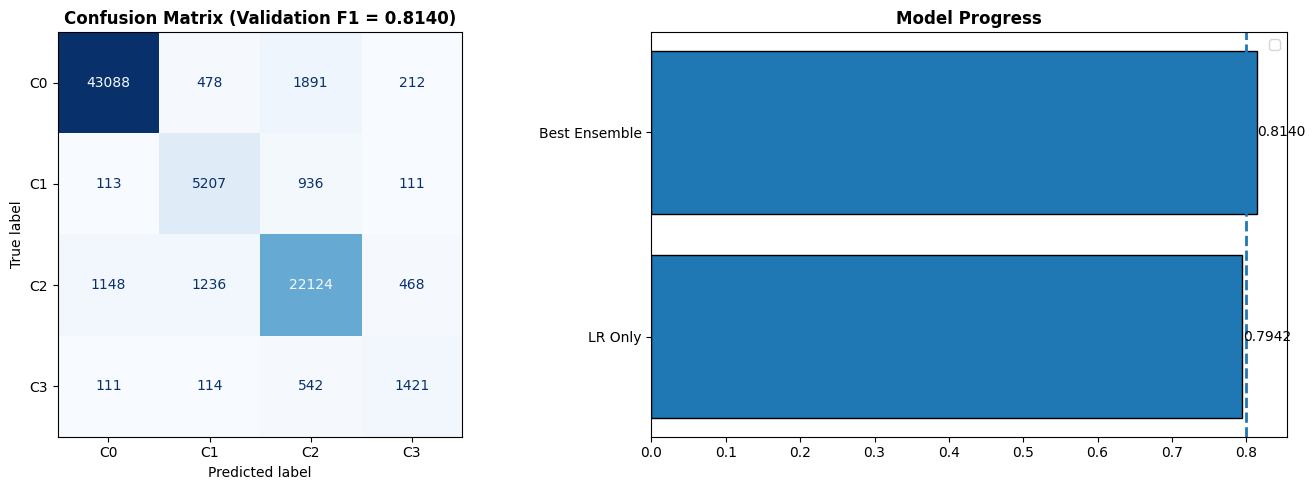

In [35]:
# Classification metrics
print(classification_report(
    y_val,
    final_val_preds,
    target_names=['Class 0','Class 1','Class 2','Class 3']
))

#Confusion Matrix
cm = confusion_matrix(y_val, final_val_preds)
error_prop = (cm.sum() - np.trace(cm)) / cm.sum()

print("\nConfusion Matrix:")
print(cm)
print(f"\nError Rate: {error_prop:.4f} ({error_prop*100:.2f}%)")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Confusion matrix plot
ConfusionMatrixDisplay(
    cm,
    display_labels=['C0','C1','C2','C3']
).plot(ax=axes[0], cmap='Blues', colorbar=False)

axes[0].set_title(
    f'Confusion Matrix (Validation F1 = {final_val_f1:.4f})',
    fontweight='bold'
)

# Progress comparison
summary_df = pd.DataFrame({
    'Config': ['LR Only', 'Best Ensemble'],
    'F1': [best_lr_f1, best_ens_f1]
})

axes[1].barh(summary_df['Config'], summary_df['F1'], edgecolor='black')
axes[1].axvline(0.80, linestyle='--', linewidth=2)

axes[1].set_title('Model Progress', fontweight='bold')
axes[1].legend()

for bar, val in zip(axes[1].patches, summary_df['F1']):
    axes[1].text(
        bar.get_width()+0.001,
        bar.get_y()+bar.get_height()/2,
        f'{val:.4f}',
        va='center'
    )

plt.tight_layout()
plt.show()

The final ensemble model was evaluated using a classification report and confusion matrix to measure precision, recall, and F1-score for each class. The visualization shows the confusion matrix and a performance comparison chart, highlighting the Logistic Regression baseline (0.7942) to the best ensemble performance (~0.8140).

# 10. Retraining on full Dataset

In [36]:
X_full  = train_eng.copy()
y_full  = train_raw['label']
sw_full = compute_sample_weight('balanced', y_full)

Xf_tab    = csr_matrix(tab_prep.transform(X_full[NUM_COLS + CAT_COLS]))
Xf_word   = tfidf_word.transform(X_full['comment'].apply(clean_text))
Xf_char   = tfidf_char.transform(X_full['comment'].apply(clean_text))
Xf_sparse = hstack([Xf_word, Xf_char, Xf_tab])
Xf_svd    = svd.transform(hstack([Xf_word, Xf_tab]))

print(f"Full sparse: {Xf_sparse.shape}  |  Full SVD: {Xf_svd.shape}")

Full sparse: (198000, 30051)  |  Full SVD: (198000, 300)


After validation, the entire training dataset (198k rows) was used to prepare the final feature matrices. Tabular, word TF-IDF, and character TF-IDF features were transformed and combined to create the full sparse feature set, while SVD was applied to obtain the reduced 300-dimension representation for models requiring dense input.

## 10.1 LR

In [37]:
lr_final = LogisticRegression(
    C=best_lr_C, max_iter=1000, class_weight='balanced',
    solver='liblinear', random_state=SEED)
lr_final.fit(Xf_sparse, y_full)
print(f" LR (C={best_lr_C}) trained ")

 LR (C=0.5) trained 


## 10.2 LightGBM

In [38]:
n_lgb = lgb_model.best_iteration_
lgb_final = lgb.LGBMClassifier(
    n_estimators=n_lgb, max_depth=7, learning_rate=0.05,
    num_leaves=63, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=0.1, class_weight='balanced',
    random_state=SEED, n_jobs=-1, verbose=-1)
lgb_final.fit(Xf_svd, y_full)
print(f" LightGBM ({n_lgb} trees) trained  ")


 LightGBM (594 trees) trained  


## 10.3 MLP

In [39]:
mlp_final = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64), activation='relu',
    max_iter=300, alpha=0.0001, learning_rate='adaptive',
    learning_rate_init=0.001, random_state=SEED)
mlp_final.fit(Xf_svd, y_full)
print(f" MLP trained  ")

 MLP trained  


After selecting the best ensemble configuration, the required models were retrained on the full training dataset (198k samples) to maximize learning before generating predictions. Logistic Regression and LightGBM were retrained with the best hyperparameters, while MLP is trained in the final ensemble configuration

# 11. Generating Final Submission

In [40]:
Xt_word_f   = tfidf_word.transform(test_eng['comment'].apply(clean_text))
Xt_char_f   = tfidf_char.transform(test_eng['comment'].apply(clean_text))
Xt_tab_f    = csr_matrix(tab_prep.transform(test_eng[NUM_COLS + CAT_COLS]))
Xt_sparse_f = hstack([Xt_word_f, Xt_char_f, Xt_tab_f])
Xt_svd_f    = svd.transform(hstack([Xt_word_f, Xt_tab_f]))

In [41]:
if not use_ensemble:
    p_test = lr_final.predict_proba(Xt_sparse_f)
else:
    cfg = best_ens_cfg
    if cfg[0] == 'LR+LGB':
        p_test = (cfg[1] * lr_final.predict_proba(Xt_sparse_f) +
                  cfg[2] * lgb_final.predict_proba(Xt_svd_f))
    elif cfg[0] == 'LR+LGB+XGB':
        p_test = (cfg[1] * lr_final.predict_proba(Xt_sparse_f) +
                  cfg[2] * lgb_final.predict_proba(Xt_svd_f) +
                  cfg[3] * xgb_final.predict_proba(Xt_svd_f))
    elif cfg[0] == 'LR+LGB+MLP':
        p_test = (cfg[1] * lr_final.predict_proba(Xt_sparse_f) +
                  cfg[2] * lgb_final.predict_proba(Xt_svd_f) +
                  cfg[3] * mlp_final.predict_proba(Xt_svd_f))

test_preds = np.argmax(p_test, axis=1)

In [42]:
submission = sample_submission.copy()
submission["label"] = test_preds
submission.to_csv('submission.csv', index=False)

print(" submission file created")

 submission file created


Test data was transformed using the same feature pipelines (TF-IDF, tabular, SVD) as training. Predictions were generated using either the best single model or weighted ensemble, and the final labels were saved in the required format for Kaggle submission.